In [1]:
from fourier_paper_reproduction_2023_09_28 import default_config, output_dir
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from misc_utils import read_jsonl_to_df, keep_serializable

from itertools import product
from pathlib import Path

import fire
import jsonlines
import numpy as np
from loguru import logger

from fourier_paper_reproduction import (
    accuracy,
    get_ipr,
    how_many_terms_to_achieve,
    how_many_terms_to_achieve_relative_weight,
    rel_fourier_weight_in_largest_terms,
    sign_overlap,
)
from fourier_supervised_cleanroom import (
    amplitude_median_bin_signal,
    amplitude_prob_median_bin_signal,
    fit_fourier_series,
    ground_state_signal,
    sign_signal,
)
from fourier_paper_reproduction_2023_09_28 import get_config
from fourier_supervised_cleanroom_2023_09_27 import get_lattice
from heisenberg_hamiltonians import HeisenbergJ1J2
from spin_lattices import KagomeLattice, SquareLattice, TriangularLattice, SpinLattice
from misc_utils import column_to as to

def visualize_coeffs(coeffs, n: int, lat: SpinLattice, **kwargs):
    
    coeffs /= np.sqrt((coeffs ** 2).sum())
    fourier_basis_data = lat.get_fourier_basis_data()
    selected_coeffs = coeffs[fourier_basis_data.reprs]
    sort_order = np.argsort(np.abs(selected_coeffs))[::-1]
    sorted_subsets = fourier_basis_data.reprs[sort_order][:n]
    sorted_coeffs = selected_coeffs[sort_order][:n]
    titles = [f"{c:.3f}" for c in sorted_coeffs]
    return lat.plot_subsets(sorted_subsets, titles, legend=False, **kwargs)

In [2]:
df = (
    read_jsonl_to_df(output_dir.glob("*/results.jsonl"))
    .fillna(keep_serializable(default_config))
    .assign(
        lattice_id=lambda df: df['lattice'],
        lattice=lambda df: df.lattice.str.replace(r"Lattice.+", "", regex=True),
    )
)

In [3]:
# df.to_csv("fourier_paper_reproduction_df.csv", index=False)

/tmp/nix-shell.LNn4kU/ipykernel_3597878/4285113721.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


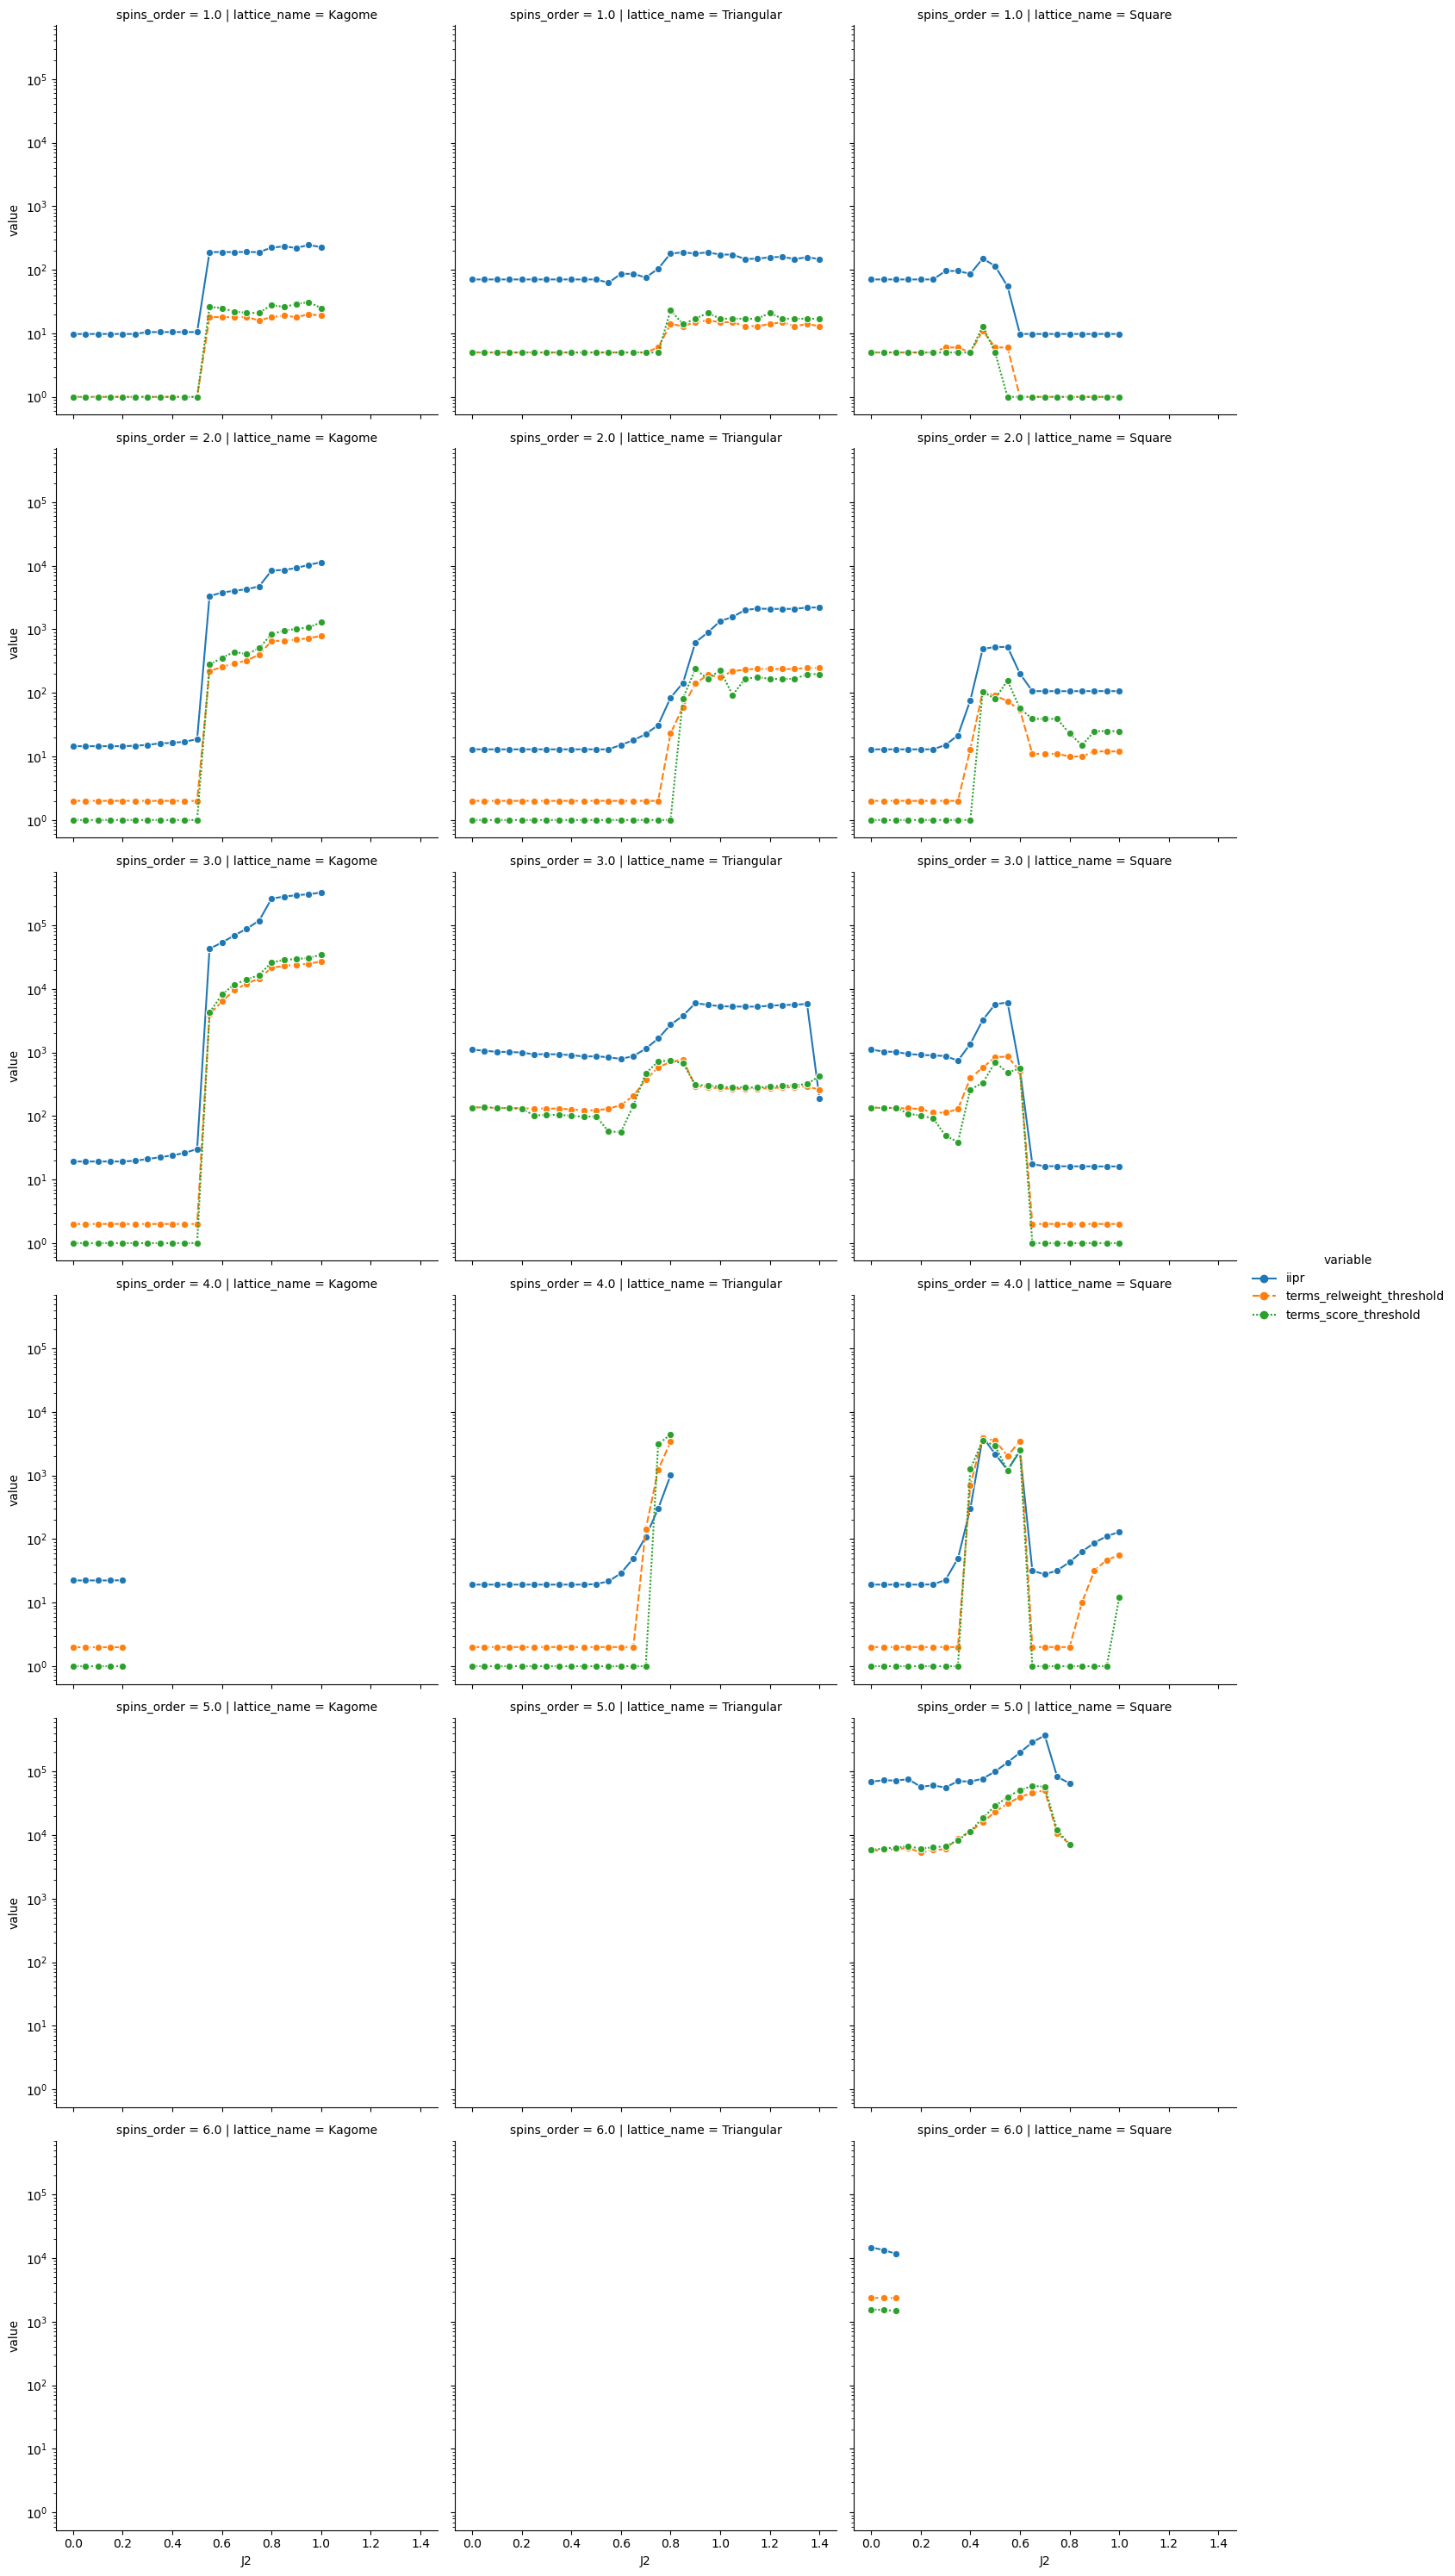

In [118]:
sns.relplot(
    df.query('scorer == "accuracy" and signal == "sign_signal"')
    .melt(
        id_vars=["J2", "lattice", "n_spins", "threshold", "iipr"],
        value_vars=["terms_score_threshold", "terms_relweight_threshold"],
    )
    .query(
        '(threshold == 0.8 and variable == "terms_score_threshold") '
        'or (threshold == 0.2 and variable == "terms_relweight_threshold")'
    )
    .drop(columns=["threshold"])
    .pivot_table(values="value", index=["J2", "lattice", "n_spins", "iipr"], columns="variable")
    .reset_index()
    .melt(
        id_vars=["J2", "lattice", "n_spins"],
        value_vars=["iipr", "terms_score_threshold", "terms_relweight_threshold"],
    )
    .sort_values("n_spins")
    .assign(
        lattice_name=lambda df: df.lattice.str.replace(r"Lattice.+", "Lattice", regex=True),
        spins_order=lambda df: df.groupby("lattice_name")['n_spins'].transform(
            lambda x: x.rank(method="dense")
        ),
    ),
    x="J2",
    y="value",
    hue="variable",
    col="lattice_name",
    row='spins_order',
    kind="line",
    markers=["o"],
    style="variable",
).set(yscale="log")

/tmp/nix-shell.uH4Kom/ipykernel_2924992/3426510079.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


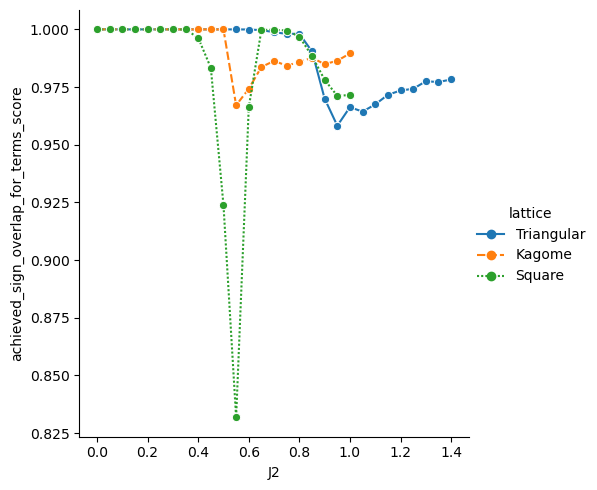

In [3]:
sns.relplot(
    df.query(
        'scorer == "accuracy" and signal == "sign_signal"' "and threshold == 0.8 and n_spins == 24"
    ),
    x="J2",
    y="achieved_sign_overlap_for_terms_score",
    hue="lattice",
    kind="line",
    style="lattice",
    markers=["o"],
)

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


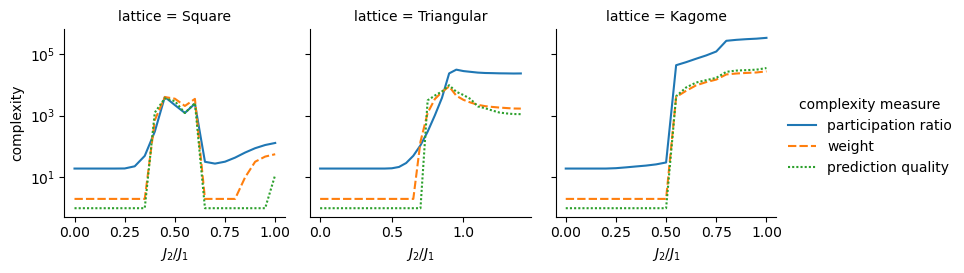

In [4]:
sns.relplot(
    df.query('scorer == "accuracy" and signal == "sign_signal"')
    .melt(
        id_vars=["J2", "lattice", "n_spins", "threshold", "iipr"],
        value_vars=["terms_score_threshold", "terms_relweight_threshold"],
    )
    .query(
        '(threshold == 0.8 and variable == "terms_score_threshold") '
        'or (threshold == 0.2 and variable == "terms_relweight_threshold")'
    )
    .drop(columns=["threshold"])
    .pivot_table(values="value", index=["J2", "lattice", "n_spins", "iipr"], columns="variable")
    .reset_index()
    .rename(
        columns={
            "iipr": "participation ratio",
            "terms_score_threshold": "prediction quality",
            "terms_relweight_threshold": "weight",
        }
    )
    .melt(
        id_vars=["J2", "lattice", "n_spins"],
        value_vars=["participation ratio", "prediction quality", "weight"],
        value_name="complexity",
        var_name="complexity measure",
    )
    .rename(columns={"lattice_name": "lattice", "J2": "$J_2/J_1$"})
    .sort_values("n_spins")
    .query("n_spins == 24"),
    x="$J_2/J_1$",
    y="complexity",
    hue="complexity measure",
    col="lattice",
    kind="line",
   # markers=["."],
    style="complexity measure",
    facet_kws={"sharex": False},
    height=2.8,
    col_order=['Square', 'Triangular', 'Kagome']
    #legend=False,
).set(yscale="log")
#plt.savefig("fig/complexity-measures.pdf", bbox_inches="tight")

In [20]:
df.query('lattice == "Triangular" and n_spins == 24')['J2'].unique()[10]

0.49999999999999994

In [3]:
frustrated_J2s = pd.DataFrame(
    [
        {"lattice": "Kagome", "J2": 1},
        {"lattice": "Square", "J2": 0.5},
        {"lattice": "Triangular", "J2": 1.4},
    ]
)

non_frustrated_J2s = pd.DataFrame(
    [
        {"lattice": "Kagome", "J2": 0.4},
        {"lattice": "Square", "J2": 0.2},
        {"lattice": "Triangular", "J2": 0.49999999999999994},
    ]
)

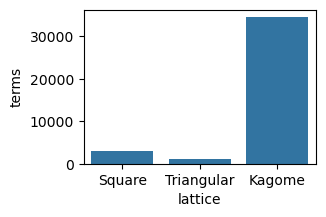

In [13]:
fig, ax = plt.subplots(figsize=(3, 2))
sns.barplot(
    df.merge(frustrated_J2s, how="right", on=["lattice", "J2"])
    .query(
        "threshold == 0.8 "
        "and n_spins == 24 "
        " and signal=='sign_signal'"
        "and scorer=='accuracy'"
    )
    .rename(columns={"terms_score_threshold": "terms"}),
    x="lattice",
    y="terms",
    order=['Square', 'Triangular', 'Kagome'],
    color='C0',
    ax=ax
)
plt.savefig('fig/complexity-of-different-lattices.pdf', bbox_inches='tight')

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


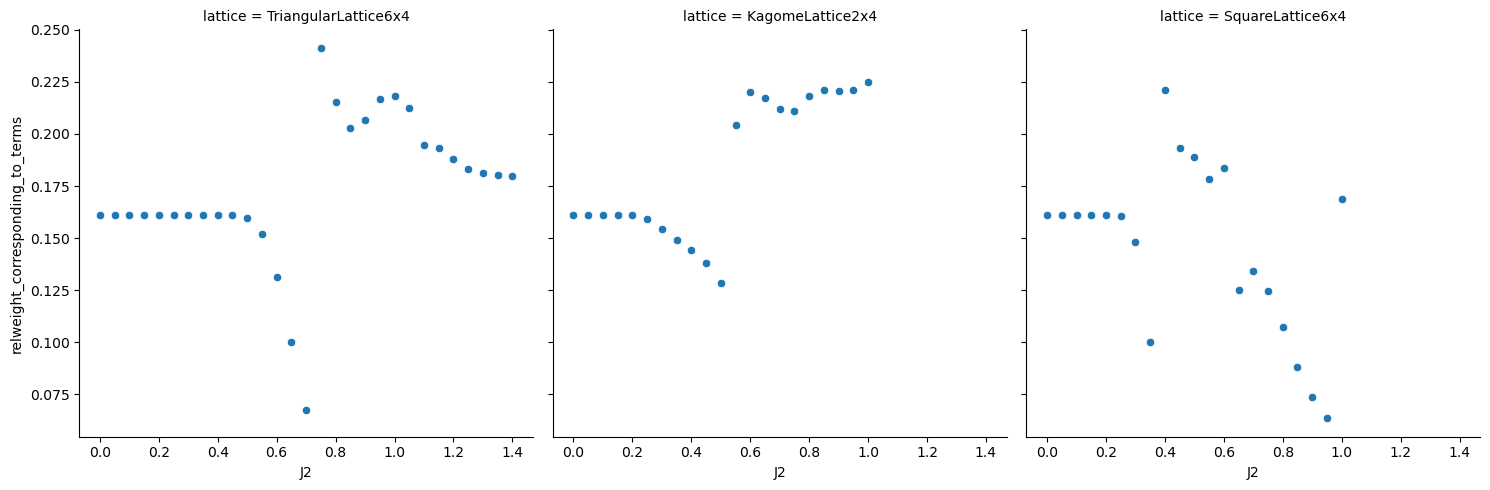

In [29]:
sns.relplot(
    df.query(
        'scorer == "accuracy" and signal == "sign_signal" and threshold == 0.8 and n_spins == 24'
    ),
    x="J2",
    y="relweight_corresponding_to_terms",
    col="lattice",
)

<Axes: xlabel='relweight_corresponding_to_terms', ylabel='Count'>

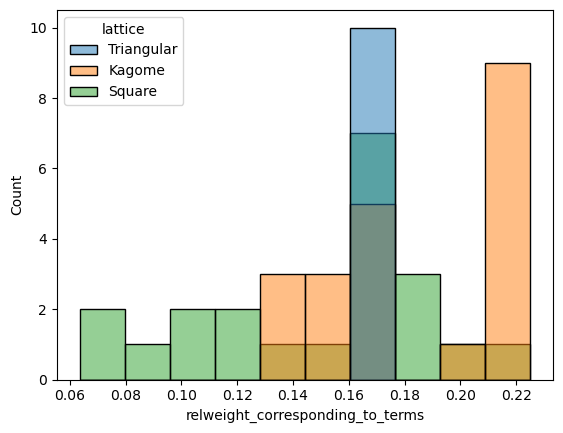

In [50]:
sns.histplot(df.query(
    'scorer == "accuracy" and signal == "sign_signal" and threshold == 0.8 and n_spins == 24'
), x='relweight_corresponding_to_terms', hue='lattice')

/tmp/nix-shell.5n1UNd/ipykernel_586863/2755644392.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


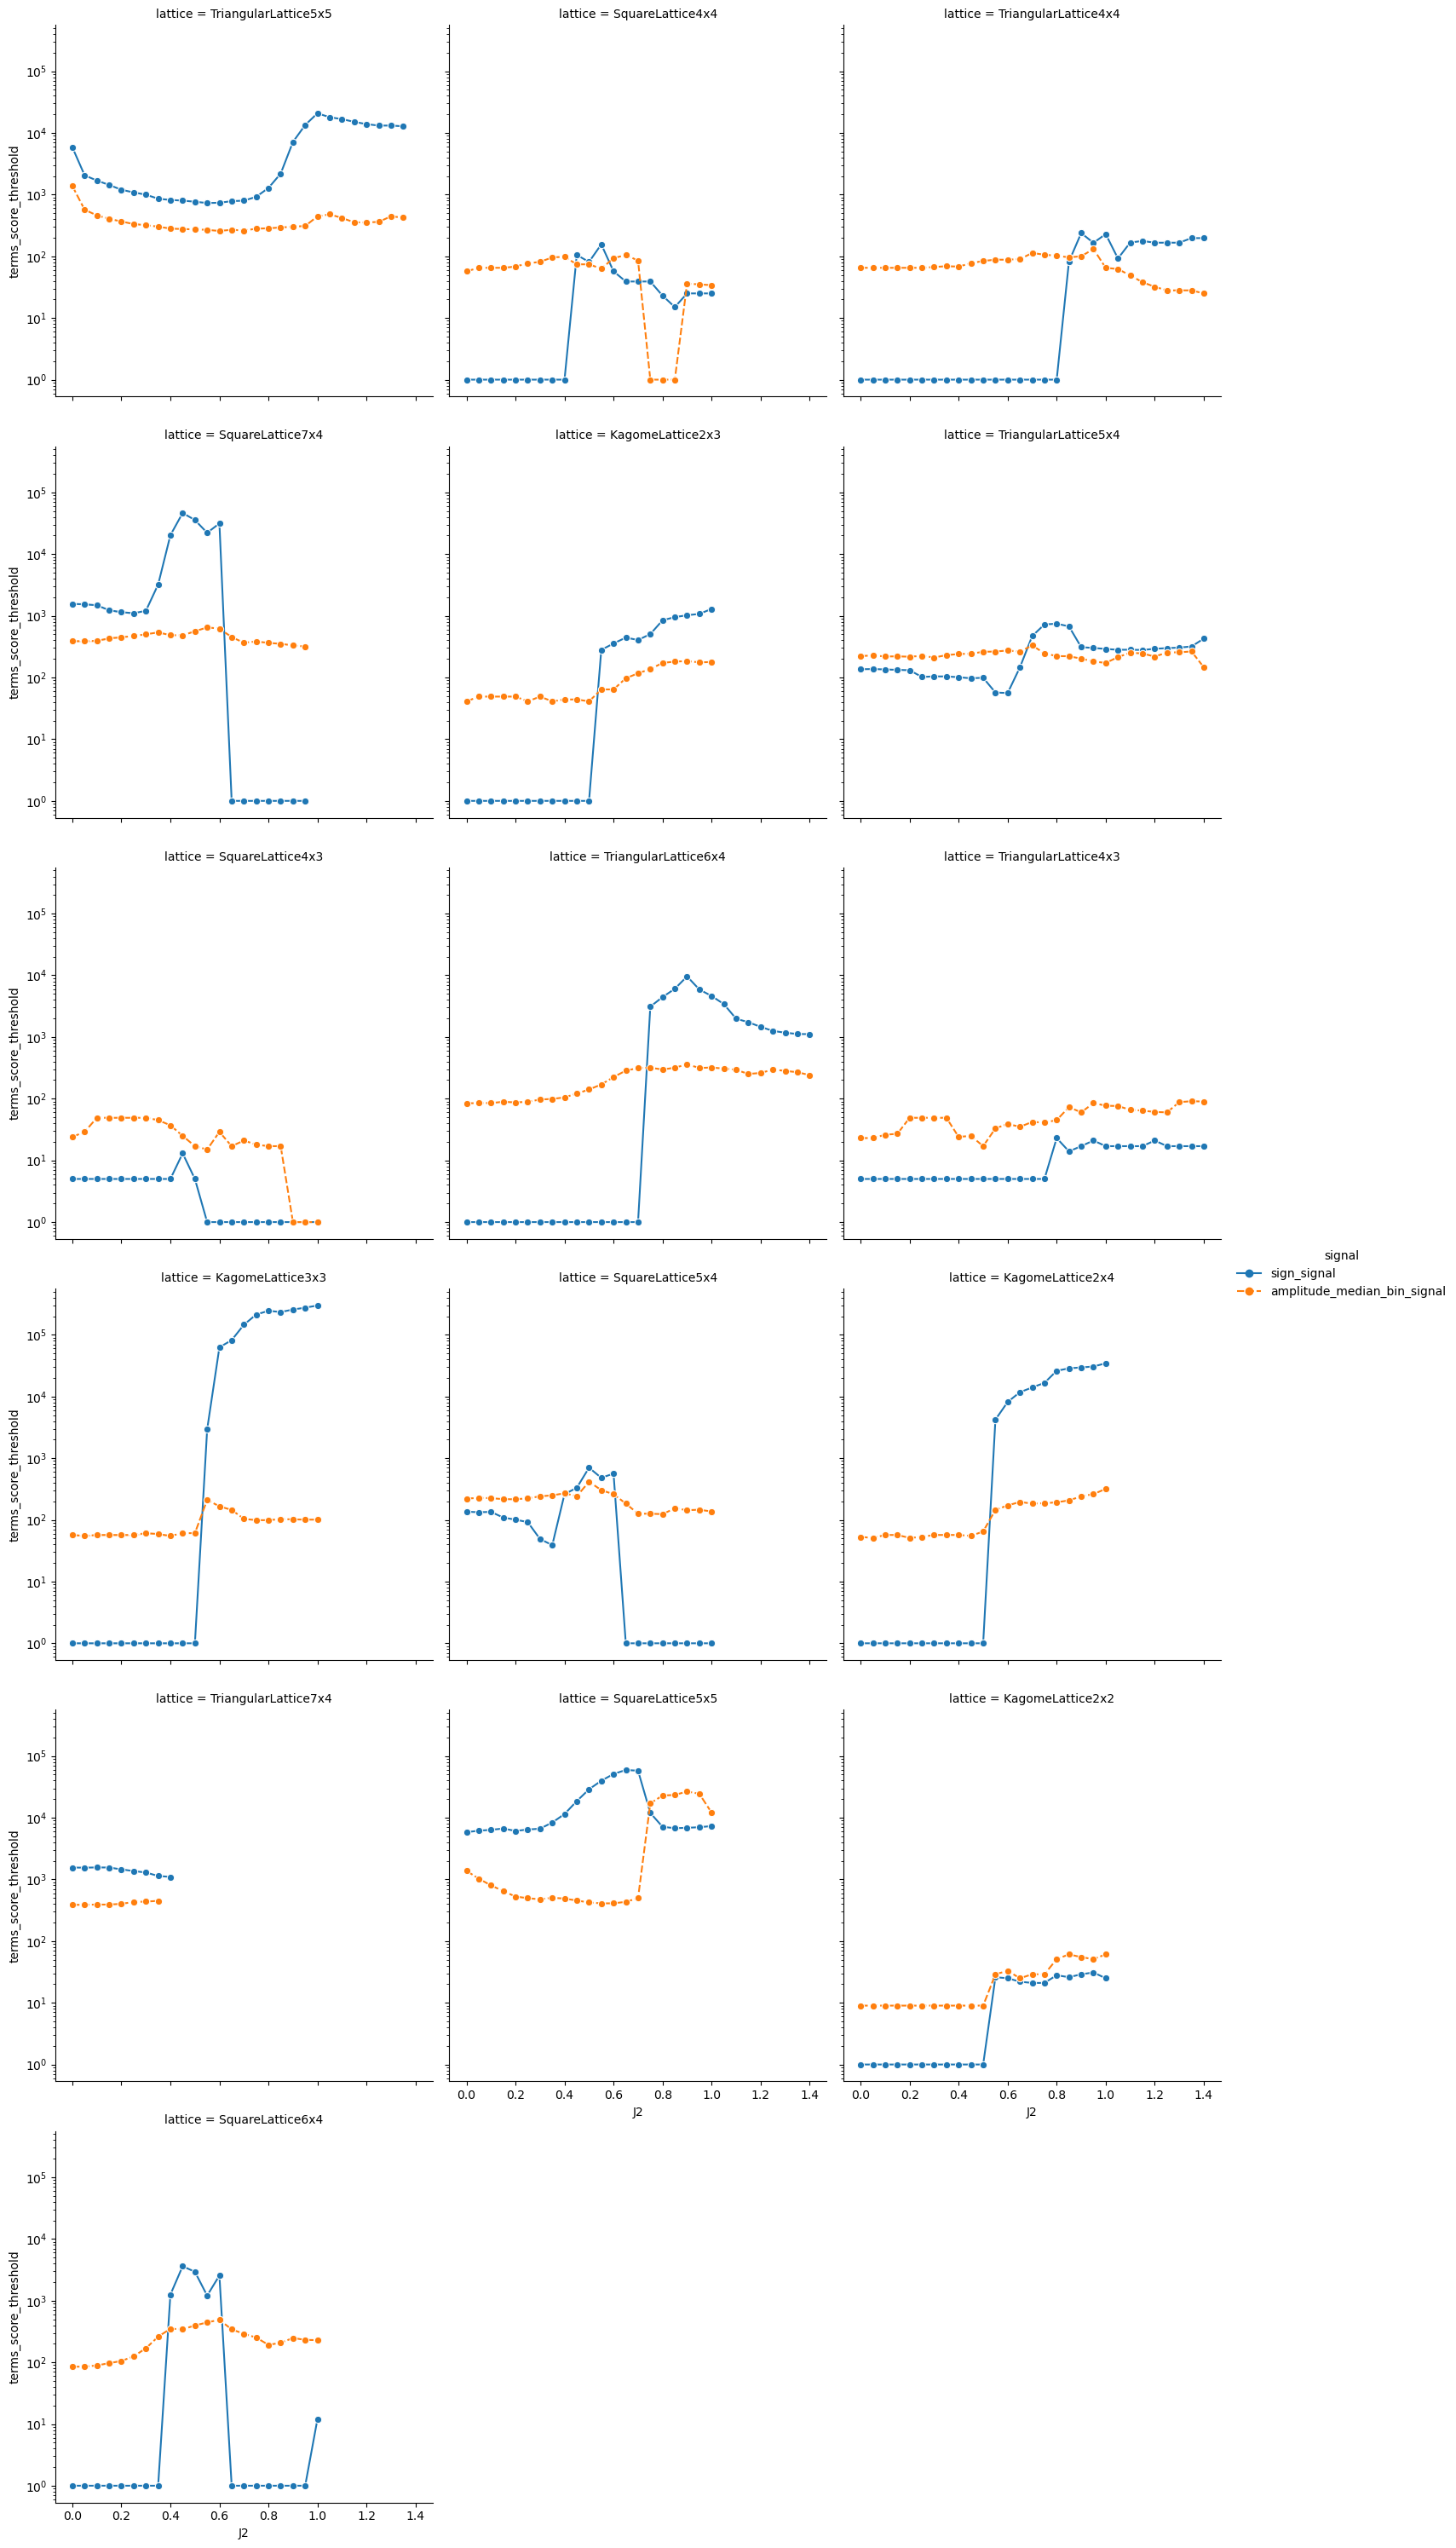

In [5]:
sns.relplot(
    df.query(
        'scorer == "accuracy" and '
        "threshold == 0.8 and "
        '(signal == "sign_signal" or signal == "amplitude_median_bin_signal")'
    ),
    x="J2",
    y="terms_score_threshold",
    hue="signal",
    col="lattice",
    col_wrap=3,
    kind="line",
    markers=["o"],
    style="signal",
).set(yscale="log")

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


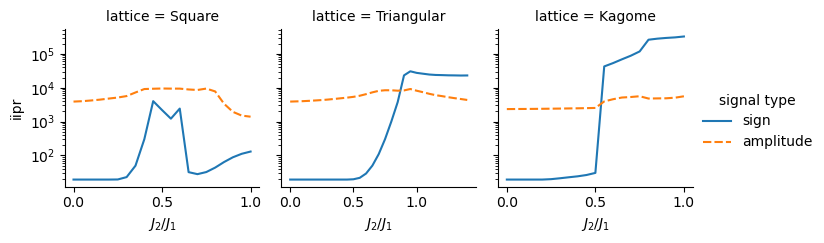

In [25]:
sns.relplot(
    df.query(
        'scorer == "accuracy"  '
        "and threshold == 0.8  "
        'and (signal == "sign_signal" or signal == "amplitude_median_bin_signal")'
        "and n_spins == 24"
    ).assign(
        signal=lambda df: df["signal"].replace(
            {"sign_signal": "sign", "amplitude_median_bin_signal": "amplitude"}
        )
    ).rename(columns={"signal": "signal type", "terms_score_threshold": "terms", "J2": "$J_2/J_1$"}),
    x="$J_2/J_1$",
    y="iipr",
    hue="signal type",
    col="lattice",
    col_order=["Square", "Triangular", "Kagome"],
    kind="line",
#    markers=["o"],
    style="signal type",
    height=2.5,
    facet_kws={"sharex": False},
).set(yscale="log")
plt.savefig("fig/signs-vs-amplitudes-complexity.pdf", bbox_inches="tight")

/tmp/nix-shell.uH4Kom/ipykernel_2924992/3628310542.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


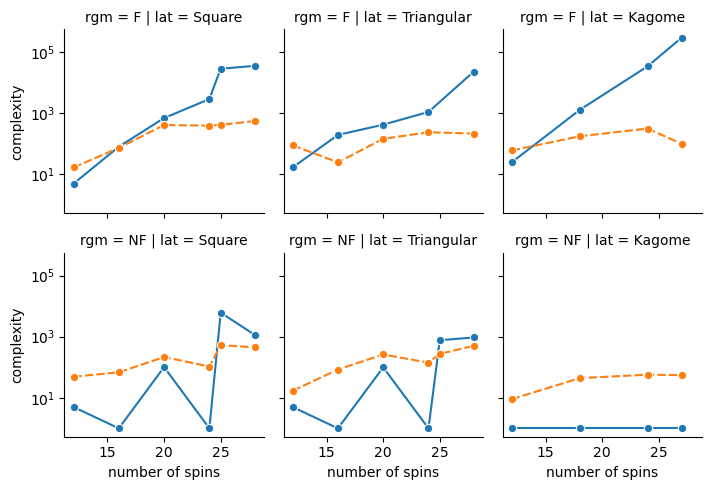

In [22]:
sns.relplot(
    pd.concat(
        [
            df.merge(frustrated_J2s, how="right", on=["lattice", "J2"]).assign(rgm="F"),
            df.merge(non_frustrated_J2s, how="right", on=["lattice", "J2"]).assign(
                rgm="NF"
            ),
        ]
    ).query(
        'scorer == "accuracy" and threshold == 0.8 '
        'and signal in ["sign_signal", "amplitude_median_bin_signal"]'
    ).rename(columns={"lattice": "lat", "terms_score_threshold": "complexity", "n_spins": "number of spins"}),
    x="number of spins",
    y="complexity",
    hue="signal",
    col="lat",
    row="rgm",
    kind="line",
    style='signal',
    markers=["o"],
    height=2.5,
    legend=False,
    col_order=["Square", "Triangular", "Kagome"],
).set(yscale="log")
plt.savefig("fig/complexity-scaling.pdf", bbox_inches="tight")

/tmp/nix-shell.5n1UNd/ipykernel_586863/2442400427.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


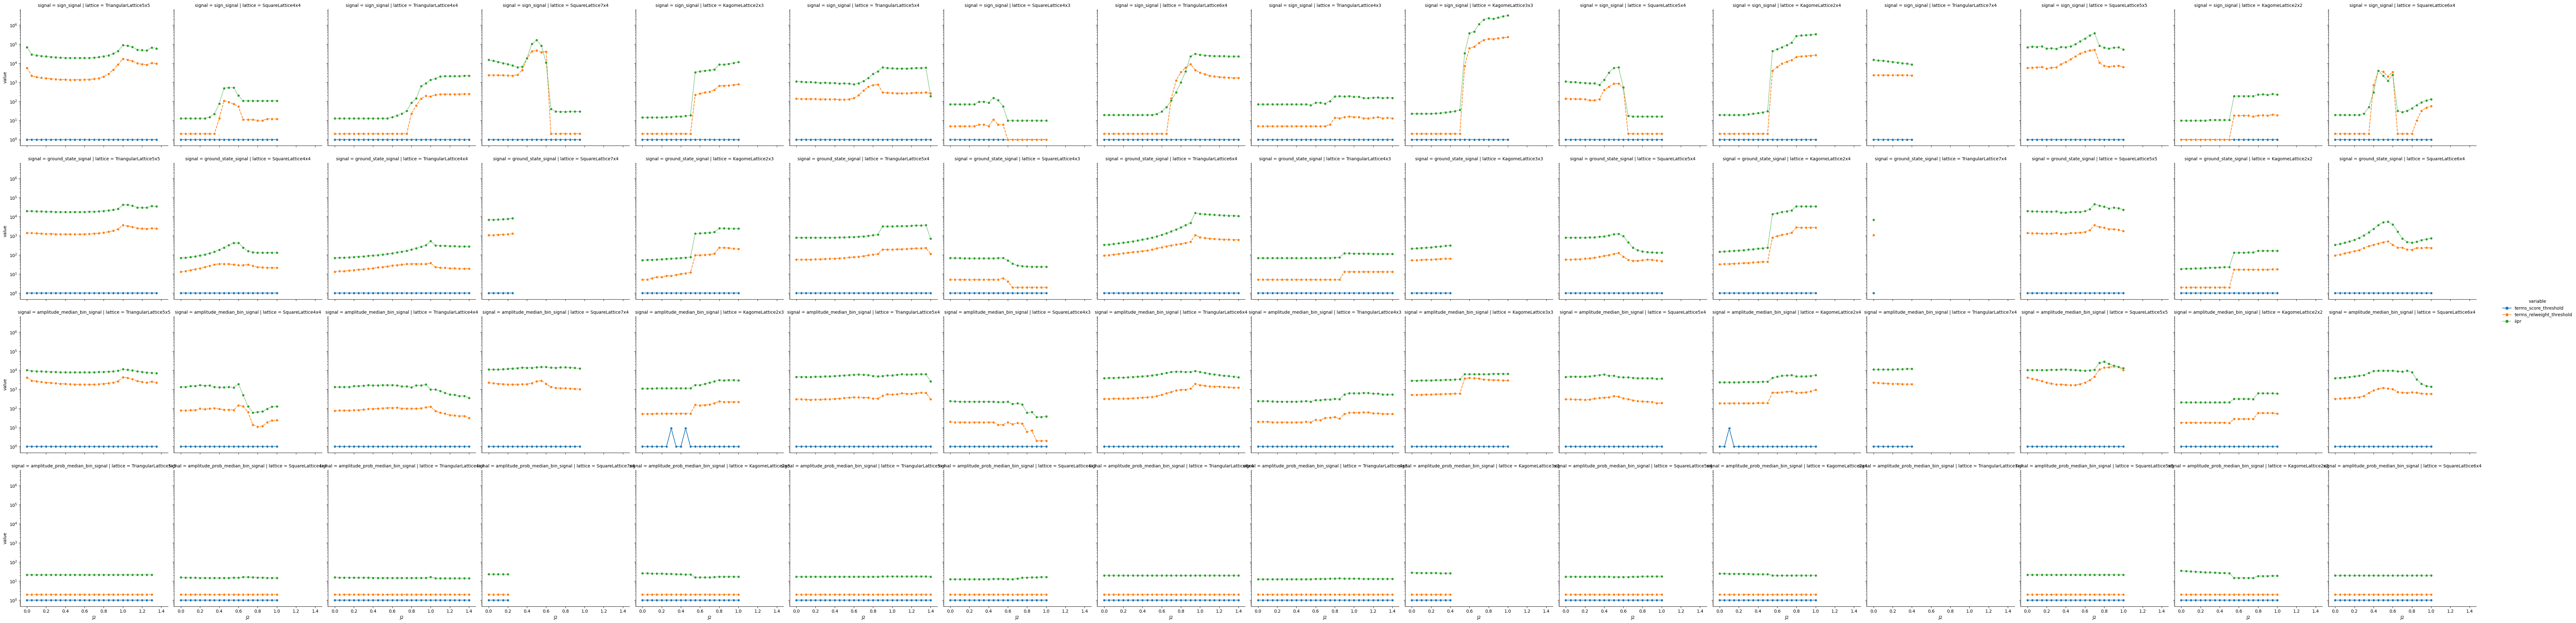

In [6]:
# sns.relplot(
#     df.query('threshold == 0.2 and scorer == "accuracy"').melt(
#         id_vars=["J2", "lattice", "n_spins", "threshold", "scorer", "signal"],
#         value_vars=["terms_score_threshold", "terms_relweight_threshold", "iipr"],
#     ),
#     x="J2",
#     y="value",
#     hue="variable",
#     col="lattice",
#     row="signal",
#     kind="line",
#     markers=["o"],
#     style="variable",
# ).set(yscale="log")

In [22]:
special_configs = pd.concat(
    [
        frustrated_J2s,
        non_frustrated_J2s,
        pd.DataFrame([{"lattice": "Square", "J2": 0.8}, {"lattice": "Triangular", "J2": 1.3}]),
    ],
    ignore_index=True,
)

In [ ]:
signal_names = {
    sign_signal: "sign",
    amplitude_median_bin_signal: "binarized amplitude",
}

In [24]:
(Path("fig") / "expansions").mkdir(exist_ok=True)

for task_id in [13, 7, 2]:
    config = get_config(task_id)
    lattice = get_lattice(config["lattice"])
    if lattice.__class__.__name__ == "KagomeLattice":
        swap_axes = True
    else:
        swap_axes = False
    fourier_basis_data = lattice.get_fourier_basis_data()
    for signal in [amplitude_median_bin_signal, sign_signal]:
        print(signal.__name__)
        for J2 in config["J2s"]:
            system = HeisenbergJ1J2(lattice, J2=J2, use_symmetries=False)
            system.get_eigenstates(1)
            signal_fn = signal(system)
            expansion = fit_fourier_series(
                system.canonical_basis.states, signal_fn, n_bits=system.number_spins
            )
            fig = visualize_coeffs(
                expansion, 7, lattice, show_numbers=False, swap_axes=swap_axes, size_scale=2
            )
            fig.suptitle(
                f"{lattice.__class__.__name__}, "
                f"{signal_names[signal]}, $J_2/J_1={J2:.2f}$"
            )
            plt.tight_layout()
            plt.show(fig)
            filename = f"expansion-{lattice.get_cache_id()}-{signal.__name__}-{J2:.2f}.pdf"
            fig.savefig(
                str(Path("fig/expansions") / filename),
                bbox_inches="tight",
            )
            if special_configs.query('lattice == @lattice.__class__.__name__.replace("Lattice", "") and J2 == @J2').shape[0] > 0:
                fig.savefig(
                str(Path("fig") / filename),
                bbox_inches="tight",
            )
            
            plt.close(fig)

2023-10-16 23:16:52.137 | DEBUG    | spin_lattices:make_fourier_basis:134 - Cached fourier_basis not found, building...


<Axes: xlabel='emb_x', ylabel='emb_y'>

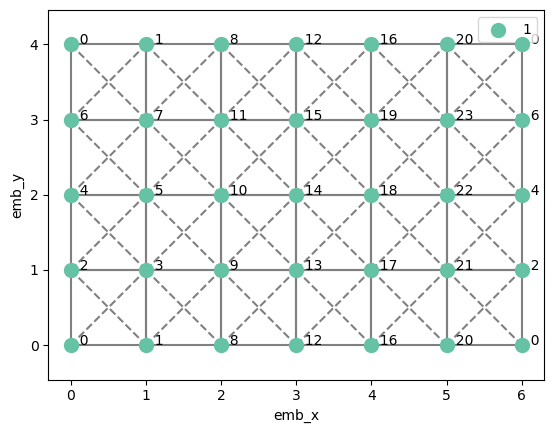

In [154]:
lattice.plot(
    spins=int(
        system.canonical_basis.index(
            np.argsort(np.abs(expansion[system.canonical_basis.states]))[::-1][0]
        )
    )
)